# WTI COT MM Nowcasting — 06 Elastic Net Investigation

**Goal**: diagnose why elastic net underperforms OOS and find a configuration
that generalises.

Hypotheses for mediocre OOS:
1. **SGDRegressor noise** — notebook 03 uses SGD-based elastic net, which adds optimiser variance
2. **HPO overfitting** — Optuna tunes alpha/l1_ratio on CPCV, which may overfit the in-sample splits
3. **Feature set** — selected features may not be stable across regimes
4. **Alpha too low** — insufficient regularisation for a small, noisy dataset

Approach:
- Use `ElasticNetCV` (coordinate descent, built-in CV for alpha) — more stable than SGD
- Walk-forward evaluation with expanding window
- Sweep l1_ratio to understand the L1/L2 tradeoff
- Track coefficient stability across refits
- Compare against plain OLS as baseline

In [1]:
import warnings; warnings.filterwarnings('ignore')
import sys; sys.path.append('../../../')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import ElasticNetCV, ElasticNet, LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

plt.rcParams['figure.figsize'] = (14, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

## 1. Load data

In [2]:
from src.utils.io.read import PreprocessedDataReader
from src.preprocessing.base import FutureTicker
from src.settings import Settings

pdr = PreprocessedDataReader(Settings.historical.paths.PREPROCESSED_DATA_PATH)
dataset = pdr.read_dataset(ticker=FutureTicker.WTI)
dataset['tradeDate'] = pd.to_datetime(dataset['tradeDate'])
dataset.sort_values('tradeDate', inplace=True)
dataset.reset_index(drop=True, inplace=True)

RESPONSES = {
    'MM Net':   'ManagedMoney_NetPosition_change',
    'MM Long':  'ManagedMoney_LongPosition_change',
    'MM Short': 'ManagedMoney_ShortPosition_change',
}

FEATURES = [
    'F1_RolledPrice_change', 'F2_RolledPrice_change', 'F3_RolledPrice_change',
    'F1_RolledPrice_rolling_20D_volatility',
    'prior_5D_AGG_OI_change', 'prior_5D_F1_OI_change',
    'prior_cumulative_5D_F1_Volume',
    'prior_cumulative_5D_F1MinusF2_Volume',
    'SyntheticF1MinusF2_RolledPrice_change',
    'prior_report_ManagedMoney_NetPosition_change',
    'prior_report_ManagedMoney_LongPosition_change',
    'prior_report_ManagedMoney_ShortPosition_change',
]
FEATURES = [f for f in FEATURES if f in dataset.columns]

resp_cols = list(RESPONSES.values())
clean = dataset[['tradeDate'] + FEATURES + resp_cols].dropna().reset_index(drop=True)
dates = clean['tradeDate'].values
X_all = clean[FEATURES].values

print(f'Rows: {len(clean)}, Features: {len(FEATURES)}')

Rows: 808, Features: 12


## 2. Walk-forward harness

In [3]:
MIN_TRAIN = 200
REFIT_EVERY = 26

def walk_forward(X, y, dates, model_fn, min_train=MIN_TRAIN, refit_every=REFIT_EVERY):
    """
    Expanding-window walk-forward.
    model_fn(X_train, y_train) -> fitted model with .predict()
    Tracks predictions AND coefficients at each refit.
    """
    T = len(y)
    preds = np.full(T, np.nan)
    coef_history = []  # (refit_date, coefs)
    model = None

    for t in range(min_train, T):
        if model is None or (t - min_train) % refit_every == 0:
            model = model_fn(X[:t], y[:t])
            # Extract coefficients if available
            if hasattr(model, 'named_steps'):
                est = model.named_steps.get('model') or model.named_steps.get('enet')
            else:
                est = model
            if hasattr(est, 'coef_'):
                coef_history.append((dates[t], est.coef_.copy(), getattr(est, 'alpha_', None)))

        preds[t] = model.predict(X[t:t+1])[0]

    oos = slice(min_train, T)
    wf = pd.DataFrame({'date': dates[oos], 'pred': preds[oos], 'actual': y[oos]})
    return wf, coef_history


def compute_metrics(wf):
    p, a = wf['pred'].values, wf['actual'].values
    mask = ~(np.isnan(p) | np.isnan(a))
    p, a = p[mask], a[mask]
    rho, _ = stats.spearmanr(p, a)
    dir_acc = np.mean(np.sign(p) == np.sign(a))
    rmse = np.sqrt(np.mean((p - a) ** 2))
    return {'rho': rho, 'dir': dir_acc, 'rmse': rmse}

print(f'OOS weeks: {len(clean) - MIN_TRAIN}')

OOS weeks: 608


## 3. Baseline: OLS

In [4]:
def fit_ols(X_train, y_train):
    pipe = Pipeline([('scaler', StandardScaler()), ('model', LinearRegression())])
    pipe.fit(X_train, y_train)
    return pipe

ols_results = {}
for label, col in RESPONSES.items():
    wf, _ = walk_forward(X_all, clean[col].values, dates, fit_ols)
    ols_results[label] = wf

ols_metrics = pd.DataFrame({l: compute_metrics(wf) for l, wf in ols_results.items()}).T
print('OLS baseline:')
print(ols_metrics.round(4).to_string())

OLS baseline:
             rho     dir        rmse
MM Net    0.4717  0.6924  22747.8068
MM Long   0.3001  0.6118  18192.0390
MM Short  0.4193  0.6595  17041.3629


## 4. ElasticNetCV walk-forward

`ElasticNetCV` uses coordinate descent (not SGD) and selects alpha via
internal time-series-safe CV. More stable than Optuna-tuned SGDRegressor.

In [5]:
L1_RATIOS_TO_TEST = [0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 1.0]

all_enet_results = {}  # {(label, l1_ratio): wf}
all_enet_coefs   = {}  # {(label, l1_ratio): coef_history}

for l1 in L1_RATIOS_TO_TEST:
    def make_fit_fn(l1_ratio):
        def fit_enet(X_train, y_train):
            scaler = StandardScaler()
            X_sc = scaler.fit_transform(X_train)
            enet = ElasticNetCV(
                l1_ratio=l1_ratio,
                n_alphas=50,
                cv=5,   # internal CV for alpha selection
                max_iter=5000,
                random_state=42,
            )
            enet.fit(X_sc, y_train)
            pipe = Pipeline([('scaler', scaler), ('enet', enet)])
            # Hack: make pipe.predict work with pre-fit components
            pipe.steps[0] = ('scaler', scaler)
            pipe.steps[1] = ('enet', enet)
            return pipe
        return fit_enet

    for label, col in RESPONSES.items():
        wf, coefs = walk_forward(X_all, clean[col].values, dates, make_fit_fn(l1))
        all_enet_results[(label, l1)] = wf
        all_enet_coefs[(label, l1)] = coefs

    m = {l: compute_metrics(all_enet_results[(l, l1)]) for l in RESPONSES}
    avg_rho = np.mean([v['rho'] for v in m.values()])
    print(f'l1_ratio={l1:.2f}: ' + ', '.join(f'{l} rho={v["rho"]:.3f}' for l, v in m.items()) + f'  (avg={avg_rho:.3f})')

l1_ratio=0.10: MM Net rho=0.217, MM Long rho=0.150, MM Short rho=0.321  (avg=0.229)


l1_ratio=0.30: MM Net rho=0.415, MM Long rho=0.267, MM Short rho=0.381  (avg=0.354)


l1_ratio=0.50: MM Net rho=0.455, MM Long rho=0.295, MM Short rho=0.392  (avg=0.381)


l1_ratio=0.70: MM Net rho=0.465, MM Long rho=0.306, MM Short rho=0.401  (avg=0.391)


l1_ratio=0.90: MM Net rho=0.467, MM Long rho=0.310, MM Short rho=0.408  (avg=0.395)


l1_ratio=0.95: MM Net rho=0.467, MM Long rho=0.311, MM Short rho=0.406  (avg=0.394)


l1_ratio=1.00: MM Net rho=0.463, MM Long rho=0.309, MM Short rho=0.401  (avg=0.391)


## 5. Compare OLS vs best ElasticNet

In [6]:
# Find best l1_ratio per response
best_l1 = {}
for label in RESPONSES:
    best_rho, best_ratio = -np.inf, None
    for l1 in L1_RATIOS_TO_TEST:
        rho = compute_metrics(all_enet_results[(label, l1)])['rho']
        if rho > best_rho:
            best_rho, best_ratio = rho, l1
    best_l1[label] = best_ratio

rows = []
for label in RESPONSES:
    ols_m = compute_metrics(ols_results[label])
    l1 = best_l1[label]
    enet_m = compute_metrics(all_enet_results[(label, l1)])
    rows.append({
        'Response': label,
        'OLS rho': ols_m['rho'], 'OLS dir': ols_m['dir'],
        f'ENet rho (l1={l1})': enet_m['rho'], f'ENet dir': enet_m['dir'],
        'best_l1': l1,
    })
comp = pd.DataFrame(rows).set_index('Response')
print(comp.round(4).to_string())

          OLS rho  OLS dir  ENet rho (l1=0.9)  ENet dir  best_l1  ENet rho (l1=0.95)
Response                                                                            
MM Net     0.4717   0.6924             0.4673    0.6826     0.90                 NaN
MM Long    0.3001   0.6118                NaN    0.6118     0.95              0.3108
MM Short   0.4193   0.6595             0.4083    0.6612     0.90                 NaN


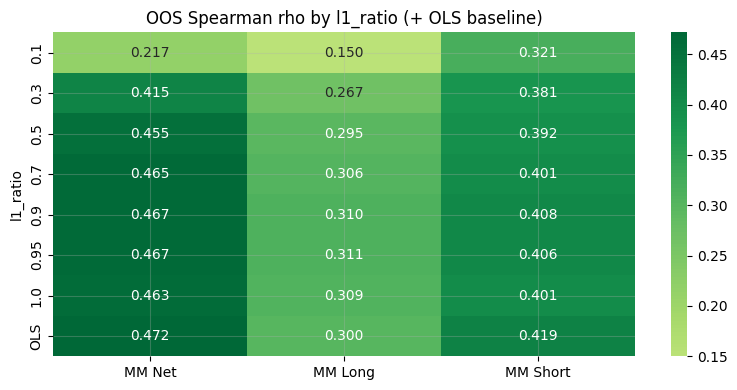

In [7]:
# Heatmap: rho by (response, l1_ratio)
heat_data = pd.DataFrame(
    {l1: {label: compute_metrics(all_enet_results[(label, l1)])['rho']
          for label in RESPONSES}
     for l1 in L1_RATIOS_TO_TEST}
).T
heat_data.index.name = 'l1_ratio'

# Add OLS row
heat_data.loc['OLS'] = {l: compute_metrics(ols_results[l])['rho'] for l in RESPONSES}

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(heat_data, annot=True, fmt='.3f', cmap='RdYlGn', center=0, ax=ax)
ax.set_title('OOS Spearman rho by l1_ratio (+ OLS baseline)')
plt.tight_layout()
plt.show()

## 6. Coefficient stability across refits

Unstable coefficients = the model is fitting noise.
Stable coefficients = the model found a reliable signal.

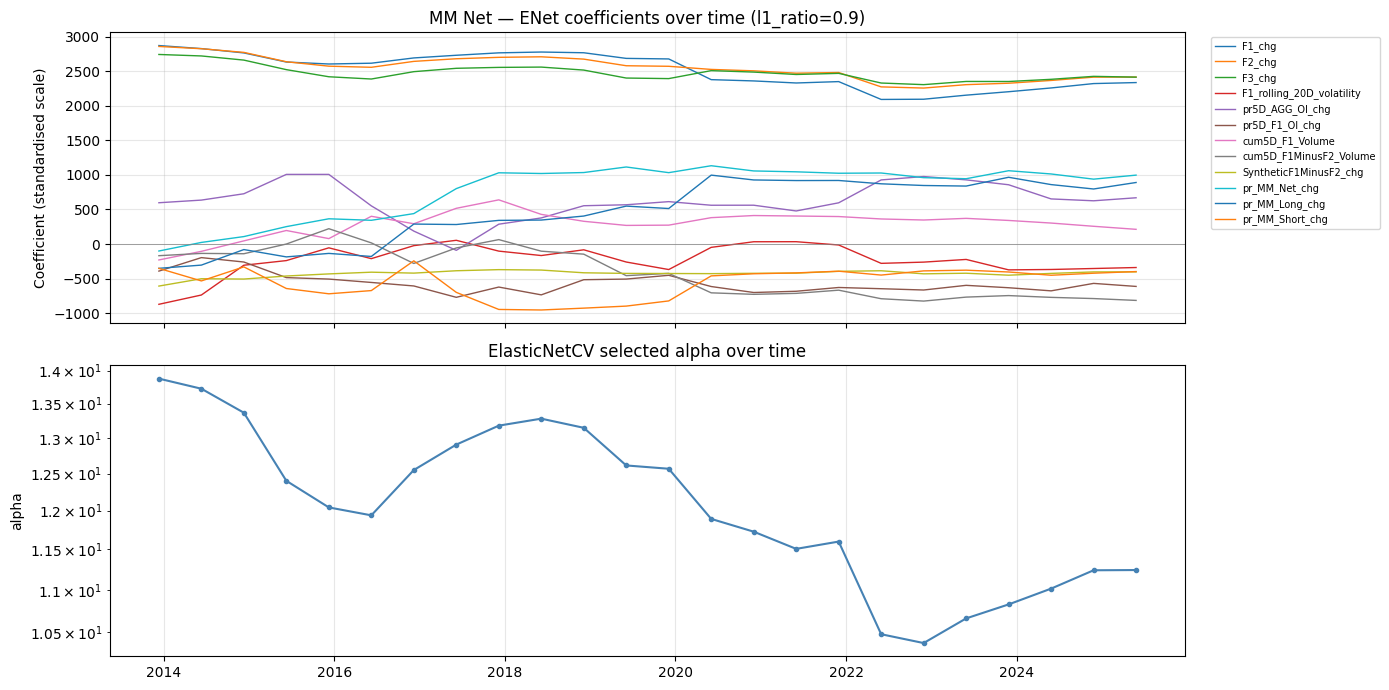

Coefficient stability (lower CV = more stable):
                  feature  mean_abs_coef   std_coef       cv  sign_changes
                   F3_chg    2475.634527 113.427903 0.045818             0
                   F2_chg    2547.680859 167.724447 0.065834             0
                   F1_chg    2512.911689 247.682028 0.098564             0
   SyntheticF1MinusF2_chg     430.549911  49.275734 0.114448             0
           pr5D_F1_OI_chg     568.362542 135.342673 0.238127             0
          pr_MM_Short_chg     555.934341 215.602074 0.387819             0
          pr5D_AGG_OI_chg     626.873311 257.536103 0.410826             2
            pr_MM_Net_chg     786.436083 386.155124 0.491019             1
          cum5D_F1_Volume     316.768455 185.026444 0.584106             1
   cum5D_F1MinusF2_Volume     439.190291 343.598638 0.782346             5
           pr_MM_Long_chg     575.014964 452.821247 0.787495             1
F1_rolling_20D_volatility     242.132147 221.918350 

In [8]:
# Plot coefficient evolution for best l1_ratio, MM Net response
label = 'MM Net'
l1 = best_l1[label]
coef_hist = all_enet_coefs[(label, l1)]

if coef_hist:
    refit_dates = [c[0] for c in coef_hist]
    coef_matrix = np.array([c[1] for c in coef_hist])
    alphas = [c[2] for c in coef_hist]

    # Short feature names
    feat_short = [
        f.replace('prior_report_ManagedMoney_', 'pr_MM_')
         .replace('prior_cumulative_5D_', 'cum5D_')
         .replace('prior_5D_', 'pr5D_')
         .replace('F1_RolledPrice_', 'F1_')
         .replace('F2_RolledPrice_', 'F2_')
         .replace('F3_RolledPrice_', 'F3_')
         .replace('SyntheticF1MinusF2_RolledPrice_', 'Synth_')
         .replace('Position_change', '_chg')
         .replace('_change', '_chg')
        for f in FEATURES
    ]

    fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

    # Coefficients over time
    ax = axes[0]
    for j, fname in enumerate(feat_short):
        ax.plot(refit_dates, coef_matrix[:, j], label=fname, linewidth=1)
    ax.axhline(0, color='grey', lw=0.5)
    ax.set_title(f'{label} — ENet coefficients over time (l1_ratio={l1})')
    ax.set_ylabel('Coefficient (standardised scale)')
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=7)

    # Alpha over time
    ax = axes[1]
    ax.plot(refit_dates, alphas, color='steelblue', marker='o', markersize=3)
    ax.set_title('ElasticNetCV selected alpha over time')
    ax.set_ylabel('alpha')
    ax.set_yscale('log')

    plt.tight_layout()
    plt.show()

    # Coefficient variability summary
    coef_std = coef_matrix.std(axis=0)
    coef_mean = np.abs(coef_matrix).mean(axis=0)
    stability = pd.DataFrame({
        'feature': feat_short,
        'mean_abs_coef': coef_mean,
        'std_coef': coef_std,
        'cv': coef_std / (coef_mean + 1e-8),  # coefficient of variation
        'sign_changes': np.sum(np.diff(np.sign(coef_matrix), axis=0) != 0, axis=0),
    }).sort_values('cv')
    print('Coefficient stability (lower CV = more stable):')
    print(stability.to_string(index=False))
else:
    print('No coefficient history available')

## 7. Feature sparsity: which features does ENet zero out?

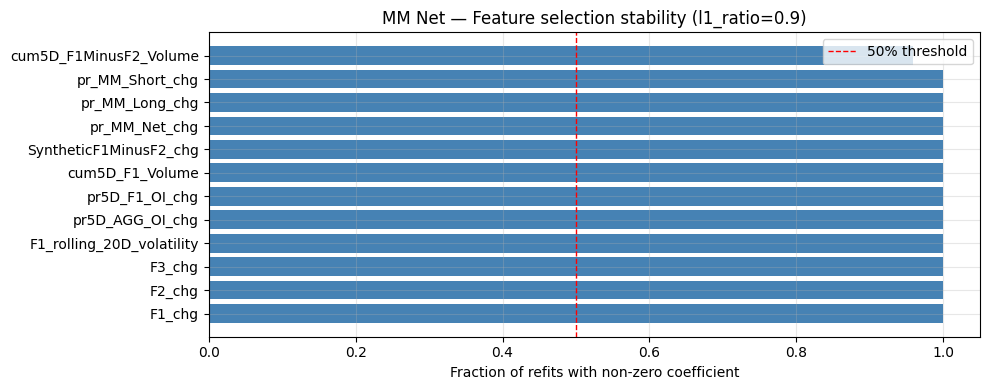

                  feature  frac_nonzero   mean_coef
                   F1_chg      1.000000 2512.911689
                   F2_chg      1.000000 2547.680859
                   F3_chg      1.000000 2475.634527
F1_rolling_20D_volatility      1.000000 -232.055348
          pr5D_AGG_OI_chg      1.000000  619.271026
           pr5D_F1_OI_chg      1.000000 -568.362542
          cum5D_F1_Volume      1.000000  288.759069
   SyntheticF1MinusF2_chg      1.000000 -430.549911
            pr_MM_Net_chg      1.000000  778.018200
           pr_MM_Long_chg      1.000000  471.846567
          pr_MM_Short_chg      1.000000 -555.934341
   cum5D_F1MinusF2_Volume      0.958333 -413.979378


In [9]:
if coef_hist:
    # Fraction of refits where each feature has a non-zero coefficient
    nonzero_frac = (np.abs(coef_matrix) > 1e-10).mean(axis=0)
    sparsity = pd.DataFrame({
        'feature': feat_short,
        'frac_nonzero': nonzero_frac,
        'mean_coef': coef_matrix.mean(axis=0),
    }).sort_values('frac_nonzero', ascending=False)

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.barh(sparsity['feature'], sparsity['frac_nonzero'], color='steelblue')
    ax.set_xlabel('Fraction of refits with non-zero coefficient')
    ax.set_title(f'{label} — Feature selection stability (l1_ratio={l1})')
    ax.axvline(0.5, color='red', linestyle='--', linewidth=1, label='50% threshold')
    ax.legend()
    plt.tight_layout()
    plt.show()

    print(sparsity.to_string(index=False))

## 8. Rolling rho comparison

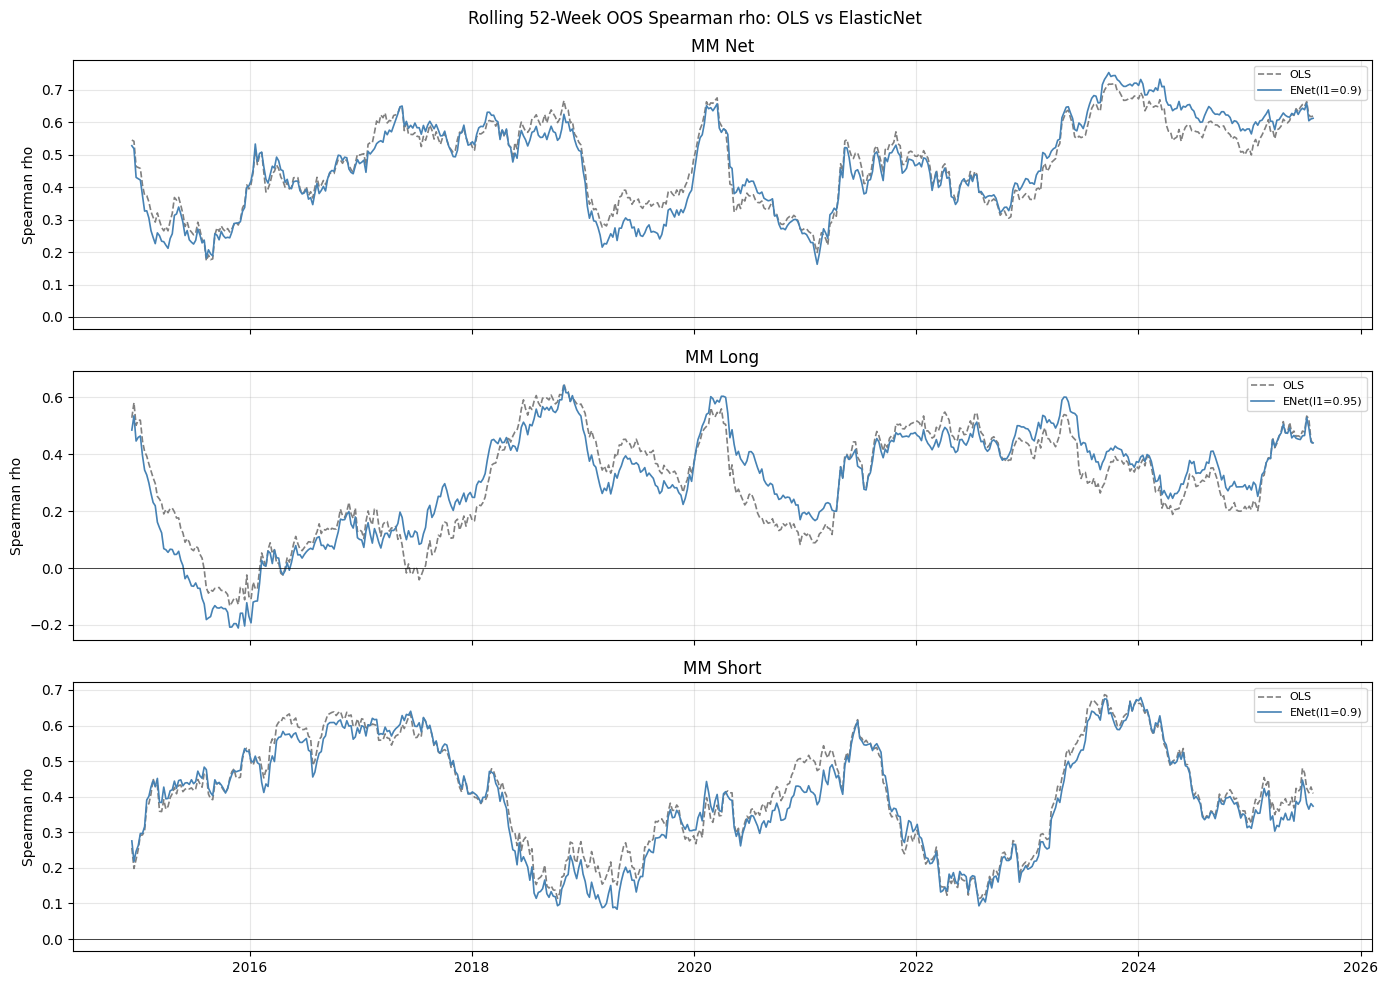

In [10]:
WINDOW = 52

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

for ax, label in zip(axes, RESPONSES):
    l1 = best_l1[label]
    for name, wf, color, ls in [
        ('OLS', ols_results[label], 'grey', '--'),
        (f'ENet(l1={l1})', all_enet_results[(label, l1)], 'steelblue', '-'),
    ]:
        p, a = wf['pred'].values, wf['actual'].values
        rolling = [
            stats.spearmanr(p[max(0,i-WINDOW):i], a[max(0,i-WINDOW):i]).statistic
            if i >= WINDOW else np.nan
            for i in range(len(p))
        ]
        ax.plot(wf['date'], rolling, label=name, color=color, linestyle=ls, linewidth=1.2)
    ax.axhline(0, color='black', lw=0.5)
    ax.set_title(f'{label}')
    ax.set_ylabel('Spearman rho')
    ax.legend(loc='upper right', fontsize=8)

plt.suptitle(f'Rolling {WINDOW}-Week OOS Spearman rho: OLS vs ElasticNet', fontsize=12)
plt.tight_layout()
plt.show()

## 9. Diagnosis summary

In [11]:
print('=== OLS vs ElasticNetCV (walk-forward, Monday-close features) ===')
print()
for label in RESPONSES:
    ols_m = compute_metrics(ols_results[label])
    l1 = best_l1[label]
    enet_m = compute_metrics(all_enet_results[(label, l1)])
    delta_rho = enet_m['rho'] - ols_m['rho']
    print(f'{label}:')
    print(f'  OLS  — rho={ols_m["rho"]:.4f}, dir={ols_m["dir"]:.1%}')
    print(f'  ENet — rho={enet_m["rho"]:.4f}, dir={enet_m["dir"]:.1%}  (l1={l1}, delta_rho={delta_rho:+.4f})')
    print()

=== OLS vs ElasticNetCV (walk-forward, Monday-close features) ===

MM Net:
  OLS  — rho=0.4717, dir=69.2%
  ENet — rho=0.4673, dir=68.3%  (l1=0.9, delta_rho=-0.0045)

MM Long:
  OLS  — rho=0.3001, dir=61.2%
  ENet — rho=0.3108, dir=61.2%  (l1=0.95, delta_rho=+0.0107)

MM Short:
  OLS  — rho=0.4193, dir=66.0%
  ENet — rho=0.4083, dir=66.1%  (l1=0.9, delta_rho=-0.0111)

